
[raw report]


,col,raw_dtype,raw_nnull,raw_ninf,raw_min,raw_max,raw_std
0,Monthly_Salary,float64,0,0,3850.0,9000.0,1372.508717
1,Overtime_Hours,int64,0,0,0.0,29.0,8.664026
2,Training_Hours,int64,0,0,0.0,99.0,28.890383
3,Remote_Work_Frequency,int64,0,0,0.0,100.0,35.351157
4,Performance_Score,int64,0,0,1.0,5.0,1.414726
5,Employee_Satisfaction_Score,float64,0,0,1.0,5.0,1.150719



[scaled report]


,col,scaled_dtype,scaled_nnull,scaled_ninf,scaled_min,scaled_max,scaled_std
0,Monthly_Salary_z,float64,0,0,-1.860251,1.892002,1.000000
1,Overtime_Hours_z,float64,0,0,-1.675310,1.671864,1.000000
2,Training_Hours_z,float64,0,0,-1.713583,1.713163,1.000000
3,Remote_Work_Frequency_minmax,float64,0,0,0.000000,1.000000,0.353512
4,Performance_Score_minmax,float64,0,0,0.000000,1.000000,0.353681
5,Employee_Satisfaction_Score_minmax,float64,0,0,0.000000,1.000000,0.287680


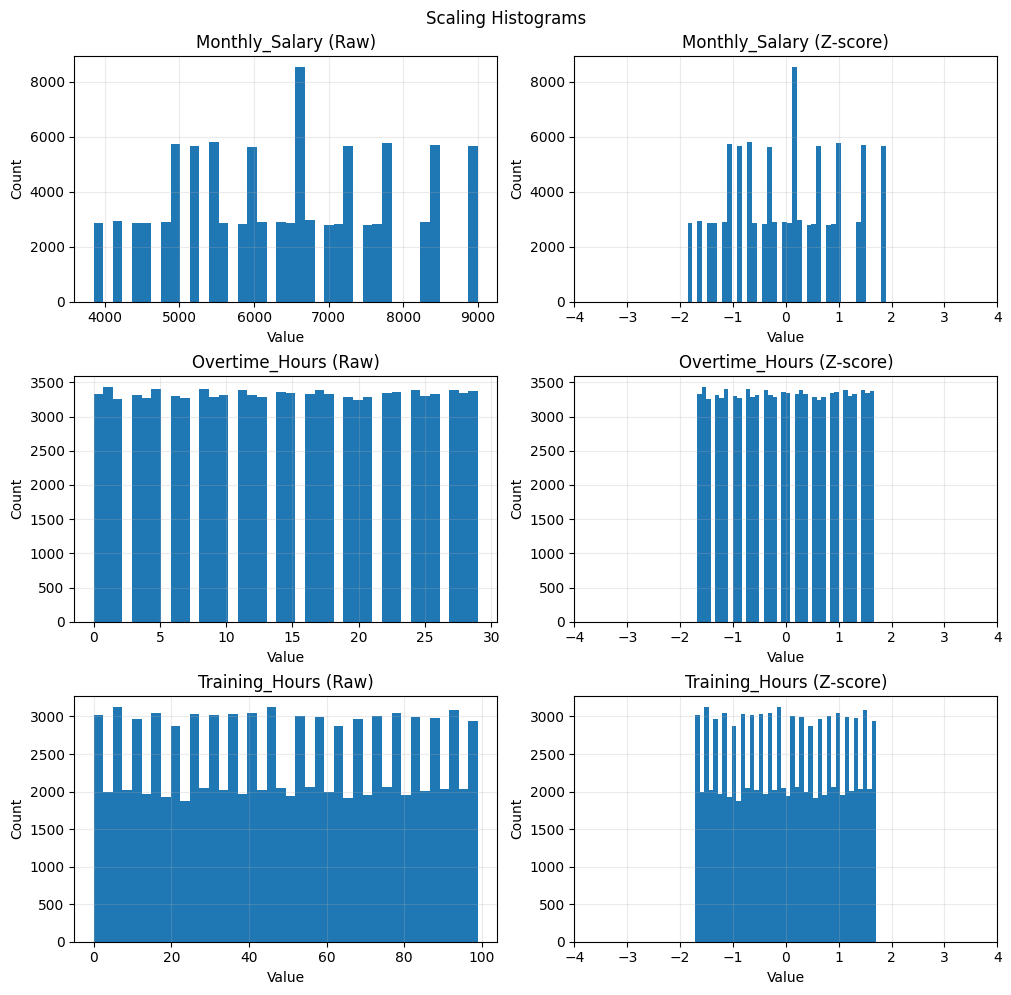

[INFO] Saved: scaling_hist_panels_zscore.png


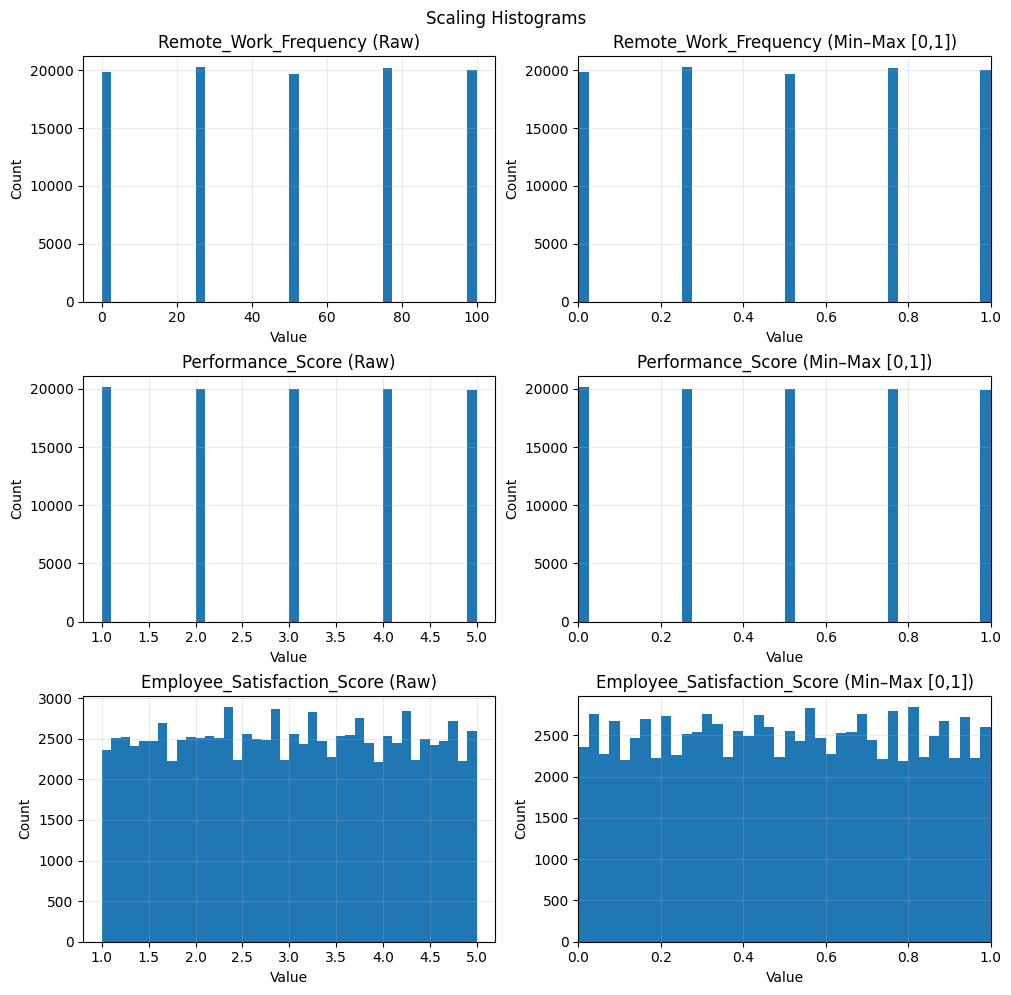

[INFO] Saved: scaling_hist_panels_minmax.png
[INFO] Scaling completed: *_z and *_minmax created without NaN.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def col_report(df, cols, tag):
    rows = []
    for c in cols:
        s = df[c]
        rows.append({
            "col": c,
            f"{tag}_dtype": s.dtype,
            f"{tag}_nnull": s.isna().sum(),
            f"{tag}_ninf": np.isinf(pd.to_numeric(s, errors="coerce")).sum() if pd.api.types.is_numeric_dtype(s) else 0,
            f"{tag}_min": pd.to_numeric(s, errors="coerce").min(),
            f"{tag}_max": pd.to_numeric(s, errors="coerce").max(),
            f"{tag}_std": pd.to_numeric(s, errors="coerce").std(),
        })
    rpt = pd.DataFrame(rows)
    print(f"\n[{tag} report]")
    display(rpt)
    return rpt

def zscore_safe(x):
    x = pd.to_numeric(x, errors="coerce")
    mu = x.mean()
    sd = x.std()
    if sd is None or sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)
    return (x - mu) / sd

def minmax_safe(x):
    x = pd.to_numeric(x, errors="coerce")
    mn = x.min()
    mx = x.max()
    if mx is None or mn is None or mx == mn or np.isnan(mx) or np.isnan(mn):
        return pd.Series(0.0, index=x.index)
    return (x - mn) / (mx - mn)

def plot_before_after_panels(df_, cols, mode="z", bins=40):
    if not cols:
        return
    n = len(cols)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 3.2 * n), constrained_layout=True)
    if n == 1:
        axes = np.array([axes])
    for i, col in enumerate(cols):
        ax_left = axes[i, 0]
        ax_left.hist(pd.to_numeric(df_[col], errors="coerce").dropna(), bins=bins)
        ax_left.set_title(f"{col} (Raw)")
        ax_left.set_xlabel("Value")
        ax_left.set_ylabel("Count")
        ax_left.grid(alpha=0.25)

        if mode == "z":
            new_col = f"{col}_z"
            xlim = (-4, 4)
            title = "Z-score"
        else:
            new_col = f"{col}_minmax"
            xlim = (0, 1)
            title = "Min–Max [0,1]"

        ax_right = axes[i, 1]
        ax_right.hist(pd.to_numeric(df_[new_col], errors="coerce").dropna(), bins=bins)
        ax_right.set_title(f"{col} ({title})")
        ax_right.set_xlabel("Value")
        ax_right.set_ylabel("Count")
        ax_right.set_xlim(*xlim)
        ax_right.grid(alpha=0.25)

    fig.suptitle("Scaling Histograms", y=1.02, fontsize=12)
    outname = f"scaling_hist_panels_{'zscore' if mode == 'z' else 'minmax'}.png"
    fig.savefig(outname, dpi=200)
    plt.show()
    print(f"[INFO] Saved: {outname}")

to_standardize = [c for c in ["Monthly_Salary", "Overtime_Hours", "Training_Hours"] if c in df.columns]
to_minmax = []
if "Remote_Work_Frequency" in df.columns:
    to_minmax.append("Remote_Work_Frequency")
for c in ["Performance_Score", "Employee_Satisfaction_Score"]:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        to_minmax.append(c)

_ = col_report(df, to_standardize + to_minmax, tag="raw")

work = df.copy()
for c in to_standardize + to_minmax:
    col = pd.to_numeric(work[c], errors="coerce")
    med = col.median()
    work[c] = col.fillna(med).replace([np.inf, -np.inf], med)

for c in to_standardize:
    work[f"{c}_z"] = zscore_safe(work[c])
for c in to_minmax:
    work[f"{c}_minmax"] = minmax_safe(work[c])

for c in to_standardize:
    df[f"{c}_z"] = work[f"{c}_z"]
for c in to_minmax:
    df[f"{c}_minmax"] = work[f"{c}_minmax"]

_ = col_report(df, [f"{c}_z" for c in to_standardize] + [f"{c}_minmax" for c in to_minmax], tag="scaled")

plot_before_after_panels(df, to_standardize, mode="z", bins=40)
plot_before_after_panels(df, to_minmax, mode="mm", bins=40)

print("[INFO] Scaling completed: *_z and *_minmax created without NaN.")


[INFO] Using: Extended_Employee_Performance_and_Productivity_Data.csv shape: (100000, 20)

[Age_bin counts]
Age_bin
<25       7608
25–34    25607
35–44    25597
45–54    25857
55+      15331

[Salary_q counts]
Salary_q
Q1    25782
Q2    25787
Q3    25571
Q4    22860


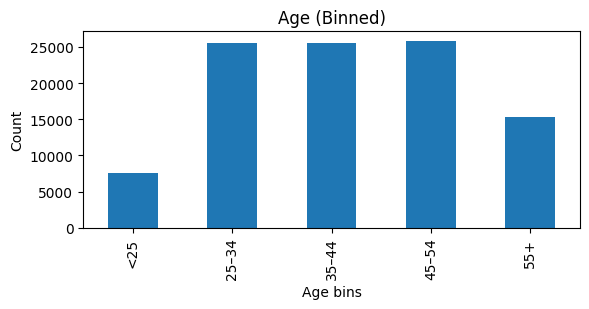

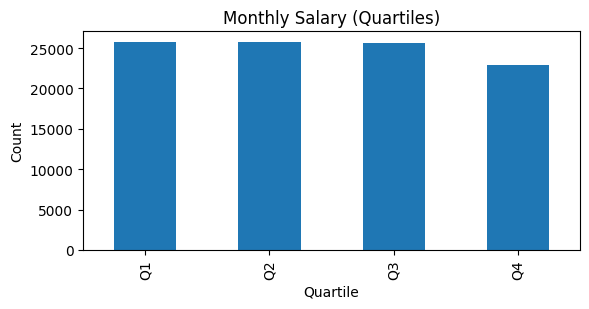


[Key correlations]
Monthly_Salary–Performance_Score: r=0.510, n=100000
Training_Hours–Employee_Satisfaction_Score: r=-0.001, n=100000
Sick_Days–Employee_Satisfaction_Score: r=-0.001, n=100000

[Max |r| among numeric pairs] 0.510

[Saved files] age_bin_counts.csv, salary_quartile_counts.csv, age_bins_bar.png, salary_quartiles_bar.png


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_csv(prefer=None):
    paths = []
    for d, _, fs in os.walk("/kaggle/input"):
        for f in fs:
            if f.lower().endswith(".csv"):
                p = os.path.join(d, f)
                paths.append(p)
                if prefer and any(k.lower() in f.lower() for k in prefer):
                    return p
    if not paths:
        raise FileNotFoundError("CSV not found under /kaggle/input")
    return paths[0]

csv_path = find_csv([
    "Extended_Employee_Performance_and_Productivity_Data.csv",
    "employee",
    "productivity"
])
df = pd.read_csv(csv_path)
print("[INFO] Using:", os.path.basename(csv_path), "shape:", df.shape)

age_bins = [0, 25, 35, 45, 55, 200]
age_labels = ["<25", "25–34", "35–44", "45–54", "55+"]
df["Age_bin"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True
)

df["Salary_q"] = pd.qcut(
    df["Monthly_Salary"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

age_counts = df["Age_bin"].value_counts().sort_index()
salary_counts = df["Salary_q"].value_counts().sort_index()

print("\n[Age_bin counts]")
print(age_counts.to_string())
print("\n[Salary_q counts]")
print(salary_counts.to_string())

age_counts.to_csv("age_bin_counts.csv")
salary_counts.to_csv("salary_quartile_counts.csv")

plt.figure(figsize=(6, 3.2))
age_counts.plot(kind="bar")
plt.title("Age (Binned)")
plt.xlabel("Age bins")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_bins_bar.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 3.2))
salary_counts.plot(kind="bar")
plt.title("Monthly Salary (Quartiles)")
plt.xlabel("Quartile")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("salary_quartiles_bar.png", dpi=150)
plt.show()

def corr_n(x, y, method="pearson"):
    d = df[[x, y]].dropna()
    r = d[x].corr(d[y], method=method)
    return r, d.shape[0]

pairs = [
    ("Monthly_Salary", "Performance_Score"),
    ("Training_Hours", "Employee_Satisfaction_Score"),
    ("Sick_Days", "Employee_Satisfaction_Score"),
]

print("\n[Key correlations]")
for a, b in pairs:
    if a in df.columns and b in df.columns:
        r, n = corr_n(a, b)
        print(f"{a}–{b}: r={r:.3f}, n={n}")
    else:
        print(f"{a}–{b}: (column missing)")

num_like = df.select_dtypes(include=[np.number]).columns
corr_abs_max = (
    df[num_like]
    .corr()
    .abs()
    .where(~np.eye(len(num_like), dtype=bool))
    .max()
    .max()
)
print(f"\n[Max |r| among numeric pairs] {corr_abs_max:.3f}")

print("\n[Saved files] age_bin_counts.csv, salary_quartile_counts.csv, age_bins_bar.png, salary_quartiles_bar.png")


[INFO] Using: Extended_Employee_Performance_and_Productivity_Data.csv shape: (100000, 20)
[INFO] Saved: outliers_iqr_summary.csv


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_ratio
0,Age,31.0,51.0,20.0,1.0,81.0,0,0.0
1,Monthly_Salary,5250.0,7500.0,2250.0,1875.0,10875.0,0,0.0
2,Work_Hours_Per_Week,37.0,53.0,16.0,13.0,77.0,0,0.0
3,Projects_Handled,12.0,37.0,25.0,-25.5,74.5,0,0.0
4,Overtime_Hours,7.0,22.0,15.0,-15.5,44.5,0,0.0
5,Sick_Days,3.0,11.0,8.0,-9.0,23.0,0,0.0
6,Team_Size,5.0,15.0,10.0,-10.0,30.0,0,0.0
7,Training_Hours,25.0,75.0,50.0,-50.0,150.0,0,0.0
8,Years_At_Company,2.0,7.0,5.0,-5.5,14.5,0,0.0
9,Promotions,0.0,2.0,2.0,-3.0,5.0,0,0.0


[INFO] Saved: outliers_z_summary.csv


,column,mean,std,z_threshold,outlier_count,outlier_ratio
0,Age,41.02941,11.244121,3.0,0,0.0
1,Monthly_Salary,6403.21100,1372.508717,3.0,0,0.0
2,Work_Hours_Per_Week,44.95695,8.942003,3.0,0,0.0
3,Projects_Handled,24.43117,14.469584,3.0,0,0.0
4,Overtime_Hours,14.51493,8.664026,3.0,0,0.0
5,Sick_Days,7.00855,4.331591,3.0,0,0.0
6,Team_Size,10.01356,5.495405,3.0,0,0.0
7,Training_Hours,49.50606,28.890383,3.0,0,0.0
8,Years_At_Company,4.47607,2.869336,3.0,0,0.0
9,Promotions,0.99972,0.815872,3.0,0,0.0


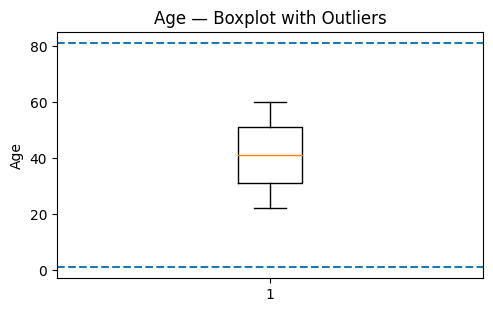

[INFO] Saved: box_with_outliers_Age.png


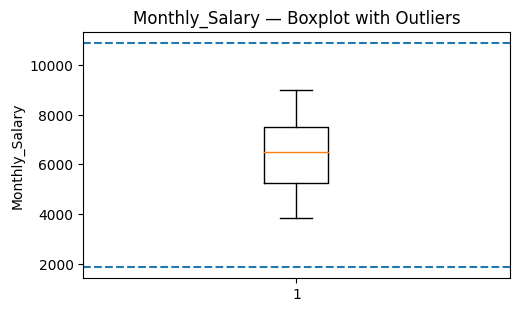

[INFO] Saved: box_with_outliers_Monthly_Salary.png


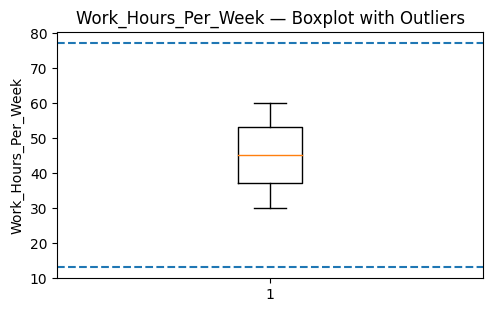

[INFO] Saved: box_with_outliers_Work_Hours_Per_Week.png


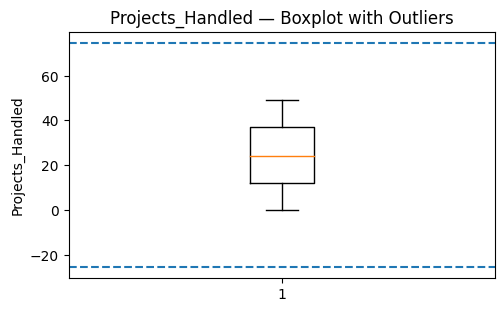

[INFO] Saved: box_with_outliers_Projects_Handled.png


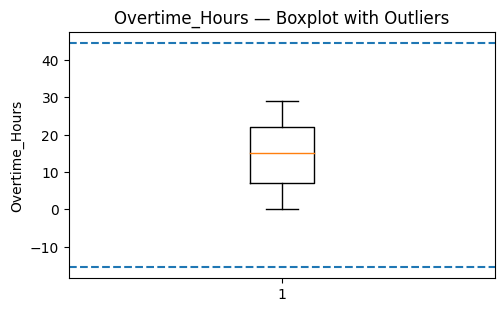

[INFO] Saved: box_with_outliers_Overtime_Hours.png


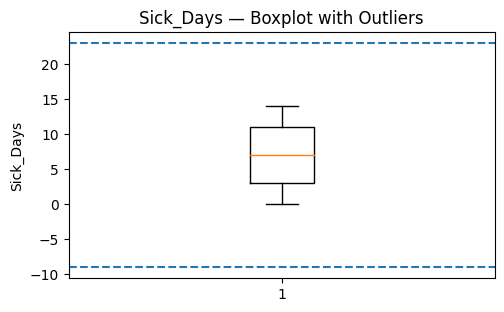

[INFO] Saved: box_with_outliers_Sick_Days.png


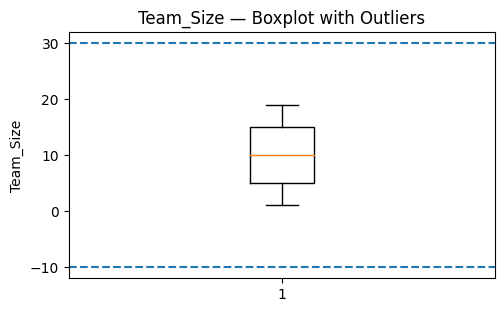

[INFO] Saved: box_with_outliers_Team_Size.png


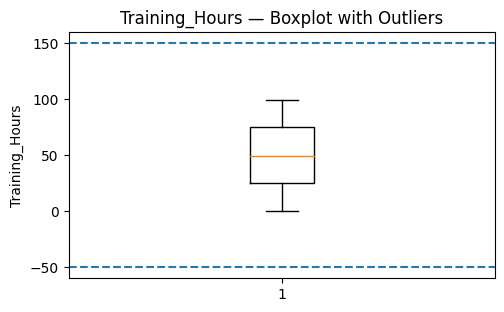

[INFO] Saved: box_with_outliers_Training_Hours.png


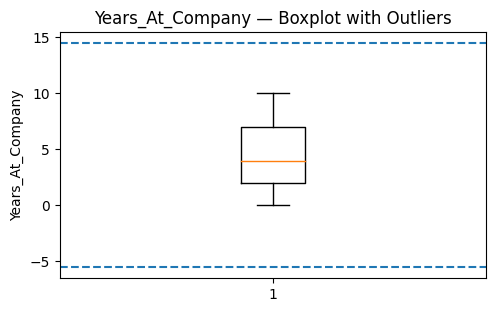

[INFO] Saved: box_with_outliers_Years_At_Company.png


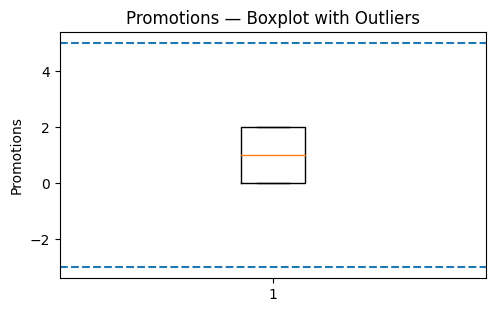

[INFO] Saved: box_with_outliers_Promotions.png
[INFO] Outlier detection completed (IQR + Z-score).


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_csv(prefer=None):
    paths = []
    for d, _, fs in os.walk("/kaggle/input"):
        for f in fs:
            if f.lower().endswith(".csv"):
                p = os.path.join(d, f)
                paths.append(p)
                if prefer and any(k.lower() in f.lower() for k in prefer):
                    return p
    if not paths:
        raise FileNotFoundError("CSV not found under /kaggle/input")
    return paths[0]

csv_path = find_csv([
    "Extended_Employee_Performance_and_Productivity_Data.csv",
    "employee",
    "productivity"
])
df = pd.read_csv(csv_path)
print("[INFO] Using:", os.path.basename(csv_path), "shape:", df.shape)

numerical = [
    c for c in [
        "Age", "Monthly_Salary", "Work_Hours_Per_Week", "Projects_Handled",
        "Overtime_Hours", "Sick_Days", "Team_Size", "Training_Hours",
        "Years_At_Company", "Promotions"
    ] if c in df.columns
]

df_num = df[numerical].apply(pd.to_numeric, errors="coerce")

def iqr_outliers(s, k=1.5):
    x = pd.to_numeric(s, errors="coerce").dropna()
    if x.empty:
        return dict(q1=np.nan, q3=np.nan, iqr=np.nan, lo=np.nan, hi=np.nan,
                    count=0, ratio=0.0, idx=[])
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    mask = (s < lo) | (s > hi)
    idx = list(s[mask].index)
    return dict(q1=q1, q3=q3, iqr=iqr, lo=lo, hi=hi,
                count=int(mask.sum()), ratio=float(mask.sum()) / len(s), idx=idx)

iqr_rows = []
for col in numerical:
    res = iqr_outliers(df_num[col], k=1.5)
    iqr_rows.append({
        "column": col,
        "q1": res["q1"],
        "q3": res["q3"],
        "iqr": res["iqr"],
        "lower_bound": res["lo"],
        "upper_bound": res["hi"],
        "outlier_count": res["count"],
        "outlier_ratio": res["ratio"],
    })
    pd.Series(res["idx"]).to_csv(f"outlier_indices_IQR_{col}.csv", index=False)

iqr_sum = pd.DataFrame(iqr_rows).sort_values("outlier_ratio", ascending=False)
iqr_sum.to_csv("outliers_iqr_summary.csv", index=False)
print("[INFO] Saved: outliers_iqr_summary.csv")
display(iqr_sum)

def zscore_outliers(s, thr=3.0):
    x = pd.to_numeric(s, errors="coerce")
    mu = x.mean()
    sd = x.std()
    if sd == 0 or np.isnan(sd):
        mask = pd.Series(False, index=s.index)
    else:
        z = (x - mu) / sd
        mask = z.abs() > thr
    idx = list(s[mask].index)
    return dict(mu=mu, sd=sd, thr=thr,
                count=int(mask.sum()), ratio=float(mask.sum()) / len(s), idx=idx)

z_rows = []
for col in numerical:
    res = zscore_outliers(df_num[col], thr=3.0)
    z_rows.append({
        "column": col,
        "mean": res["mu"],
        "std": res["sd"],
        "z_threshold": 3.0,
        "outlier_count": res["count"],
        "outlier_ratio": res["ratio"],
    })
    pd.Series(res["idx"]).to_csv(f"outlier_indices_Z_{col}.csv", index=False)

z_sum = pd.DataFrame(z_rows).sort_values("outlier_ratio", ascending=False)
z_sum.to_csv("outliers_z_summary.csv", index=False)
print("[INFO] Saved: outliers_z_summary.csv")
display(z_sum)

def plot_box_with_outliers(df_, col, lo=None, hi=None):
    x = pd.to_numeric(df_[col], errors="coerce")
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    ax.boxplot(x.dropna().values, vert=True, showfliers=True)
    ax.set_title(f"{col} — Boxplot with Outliers")
    ax.set_ylabel(col)
    if lo is not None and hi is not None:
        ax.axhline(lo, ls="--")
        ax.axhline(hi, ls="--")
    fig.savefig(f"box_with_outliers_{col}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Saved: box_with_outliers_{col}.png")

iqr_bounds = {
    r["column"]: (r["lower_bound"], r["upper_bound"])
    for _, r in iqr_sum.iterrows()
}
for col in numerical:
    lo, hi = iqr_bounds.get(col, (None, None))
    plot_box_with_outliers(df_num, col, lo=lo, hi=hi)

print("[INFO] Outlier detection completed (IQR + Z-score).")

# Optional winsorization example (disabled)
# from scipy.stats.mstats import winsorize
# for col in ["Monthly_Salary", "Overtime_Hours"]:
#     x = pd.to_numeric(df[col], errors="coerce").values
#     x_win = winsorize(x, limits=(0.01, 0.01))
#     df[col + "_wins"] = x_win
# df.to_csv("employee_winsorized_example.csv", index=False)


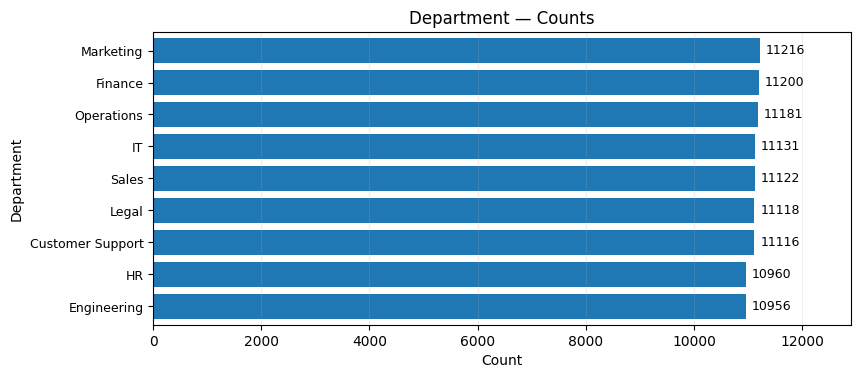

[INFO] Saved: Department_counts_pretty.png


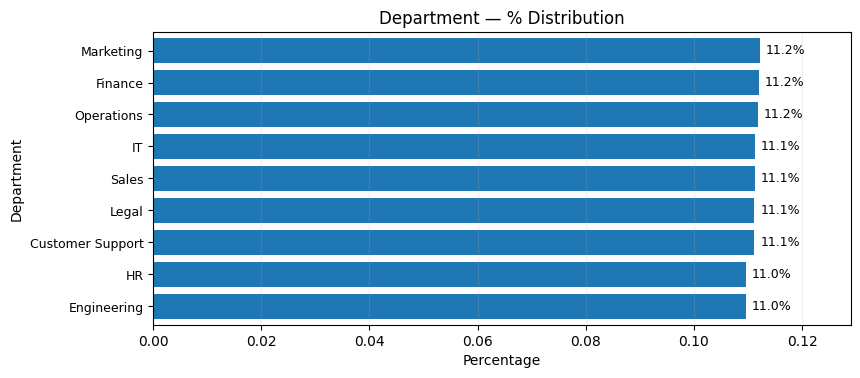

[INFO] Saved: Department_pct_pretty.png


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def nice_cat_plot(df, col, normalize=False, top=None, fname=None):
    ser = df[col].value_counts(dropna=False, normalize=normalize).sort_values(ascending=True)
    if top is not None and len(ser) > top:
        ser = ser.tail(top)

    n = len(ser)
    h = max(3.8, 0.38 * n)
    fig, ax = plt.subplots(figsize=(9, h), constrained_layout=False)

    ax.barh(range(n), ser.values, height=0.8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(ser.index, fontsize=9)
    ax.set_xlabel("Percentage" if normalize else "Count", fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(f"{col} — {'% Distribution' if normalize else 'Counts'}", fontsize=12)

    xmax = ser.values.max()
    ax.set_xlim(0, xmax * 1.15)
    for y, v in enumerate(ser.values):
        label = f"{v:.1%}" if normalize else f"{int(v)}"
        ax.text(v * 1.01, y, label, va="center", fontsize=9)

    ax.grid(axis="x", alpha=0.2)
    plt.margins(y=0.02)
    out = fname or f"{col}_{'pct' if normalize else 'counts'}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Saved:", out)

nice_cat_plot(df, "Department", normalize=False, fname="Department_counts_pretty.png")
nice_cat_plot(df, "Department", normalize=True, fname="Department_pct_pretty.png")
